In [1]:
# Restart kernel to clear cached imports
import importlib
import sys

# Remove cached modules
if 'src.pipeline.data_processor' in sys.modules:
    del sys.modules['src.pipeline.data_processor']
if 'src.pipeline.feature_engineer' in sys.modules:
    del sys.modules['src.pipeline.feature_engineer']
if 'src.utils.config' in sys.modules:
    del sys.modules['src.utils.config']

print("Modules cleared, reimporting...")

Modules cleared, reimporting...


# Feature Engineering
This notebook demonstrates the comprehensive feature engineering pipeline including:
- Sequence features (order, recency, frequency)
- Job text features (NLP-based similarity)
- Session behavior features (action patterns)

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.pipeline.data_processor import DataProcessor

sns.set_style('whitegrid')
%matplotlib inline

## 1. Load Data

In [2]:
# Initialize data processor
processor = DataProcessor()
jobs, x_train, y_train, x_test = processor.load_data()

print(f"Jobs: {len(jobs)}")
print(f"Train sessions: {len(x_train)}")
print(f"Test sessions: {len(x_test)}")

Jobs: 21917
Train sessions: 15882
Test sessions: 1819


## 2. Prepare Sequences

In [13]:
# Prepare sequences (parse lists from strings)
x_train = processor.prepare_sequences(x_train)
x_test = processor.prepare_sequences(x_test)

print("\nSample data:")
x_train.head()


Sample data:


,session_id,job_ids,actions,jobs_list,actions_list,seq_length
0,0,"[305, 299, 300, 290, 282, 274, 264, 261]","['view', 'view', 'view', 'view', 'view', 'view...","[305, 299, 300, 290, 282, 274, 264, 261]","[view, view, view, view, view, view, view, view]",8
1,1,"[84, 257, 252, 250]","['view', 'view', 'view', 'view']","[84, 257, 252, 250]","[view, view, view, view]",4
2,2,"[241, 237, 221, 309, 310, 306, 301]","['view', 'view', 'apply', 'apply', 'apply', 'a...","[241, 237, 221, 309, 310, 306, 301]","[view, view, apply, apply, apply, apply, apply]",7
3,3,"[303, 297, 296, 298, 294, 295, 292, 293]","['apply', 'apply', 'apply', 'apply', 'apply', ...","[303, 297, 296, 298, 294, 295, 292, 293]","[apply, apply, apply, apply, apply, apply, app...",8
4,4,"[171, 291, 289, 166, 288, 155]","['apply', 'apply', 'apply', 'apply', 'apply', ...","[171, 291, 289, 166, 288, 155]","[apply, apply, apply, apply, apply, apply]",6


## 3. Extract Sequence Features
Features based on order, recency, and frequency of jobs in sequences

In [4]:
# Extract sequence features only
x_train_seq = processor.add_features(x_train, feature_types=['sequence'])

# Display new sequence features
sequence_cols = [col for col in x_train_seq.columns if col not in x_train.columns]
print(f"\nSequence features added ({len(sequence_cols)}):")
print(sequence_cols)

# Show sample
x_train_seq[['session_id', 'seq_length', 'unique_jobs_count', 
             'most_frequent_job_count', 'job_transitions', 'max_consecutive_views']].head(10)

Extracting sequence features...

Sequence features added (15):
['first_job', 'last_job', 'second_job', 'second_last_job', 'unique_jobs_count', 'unique_jobs_ratio', 'most_frequent_job', 'most_frequent_job_count', 'most_frequent_job_ratio', 'job_last_positions', 'avg_job_position', 'job_transitions', 'job_transitions_ratio', 'max_consecutive_views', 'avg_consecutive_views']


,session_id,seq_length,unique_jobs_count,most_frequent_job_count,job_transitions,max_consecutive_views
0,0,8,8,1,7,1
1,1,4,4,1,3,1
2,2,7,7,1,6,1
3,3,8,8,1,7,1
4,4,6,6,1,5,1
5,5,4,4,1,3,1
6,6,4,4,1,3,1
7,7,3,3,1,2,1
8,8,6,6,1,5,1
9,9,9,9,1,8,1


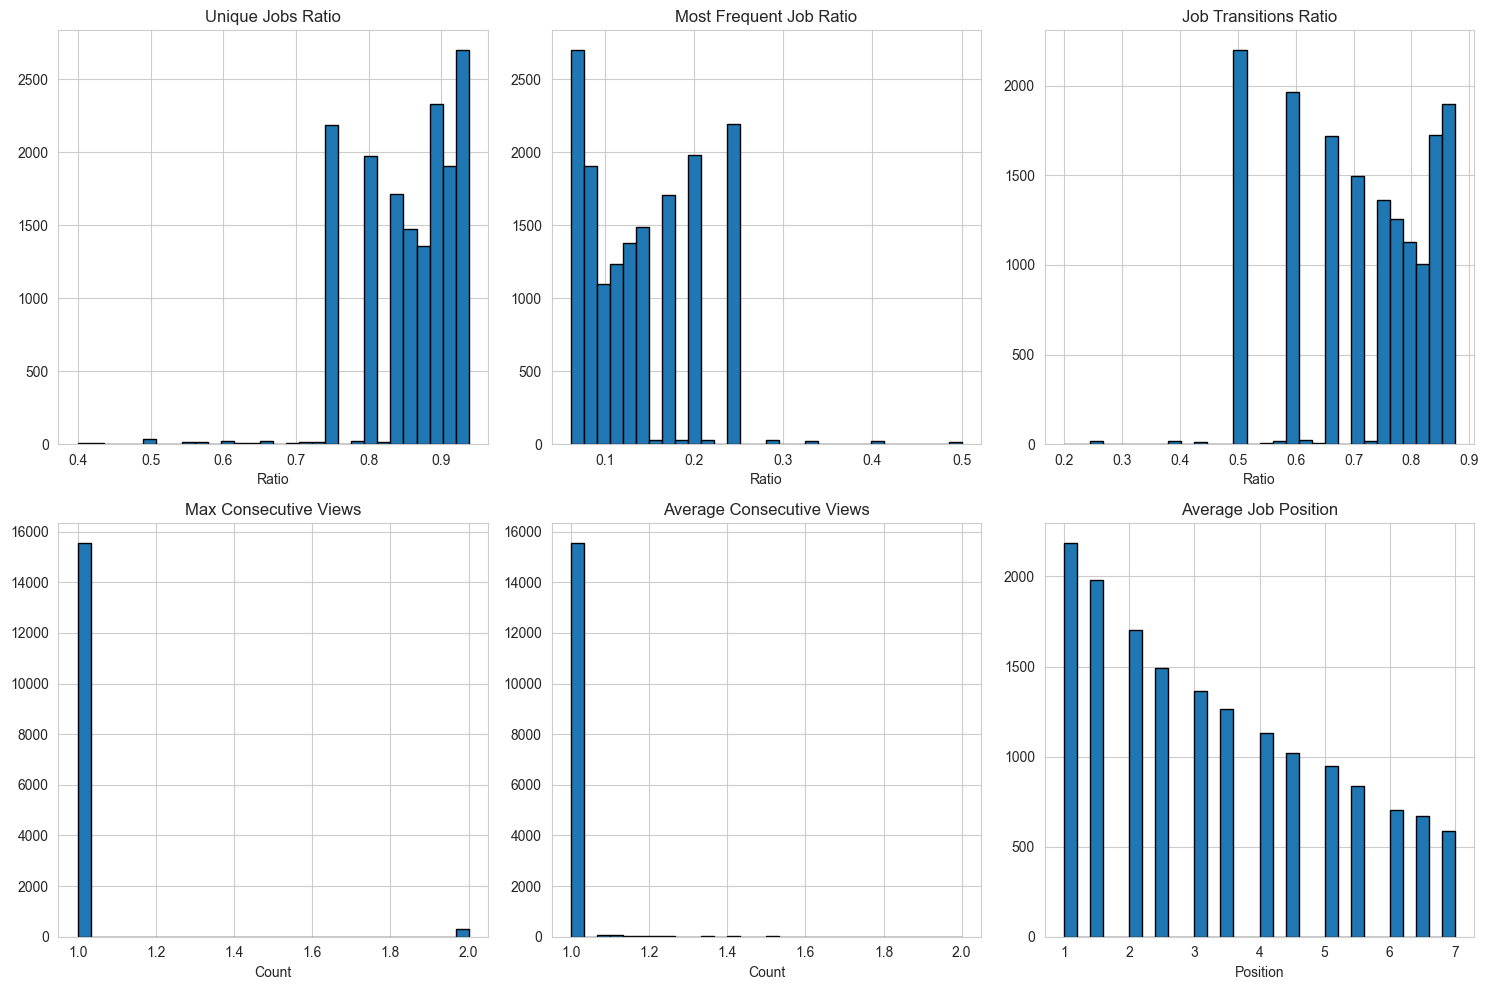

In [5]:
# Visualize sequence features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].hist(x_train_seq['unique_jobs_ratio'], bins=30, edgecolor='black')
axes[0, 0].set_title('Unique Jobs Ratio')
axes[0, 0].set_xlabel('Ratio')

axes[0, 1].hist(x_train_seq['most_frequent_job_ratio'], bins=30, edgecolor='black')
axes[0, 1].set_title('Most Frequent Job Ratio')
axes[0, 1].set_xlabel('Ratio')

axes[0, 2].hist(x_train_seq['job_transitions_ratio'], bins=30, edgecolor='black')
axes[0, 2].set_title('Job Transitions Ratio')
axes[0, 2].set_xlabel('Ratio')

axes[1, 0].hist(x_train_seq['max_consecutive_views'], bins=30, edgecolor='black')
axes[1, 0].set_title('Max Consecutive Views')
axes[1, 0].set_xlabel('Count')

axes[1, 1].hist(x_train_seq['avg_consecutive_views'], bins=30, edgecolor='black')
axes[1, 1].set_title('Average Consecutive Views')
axes[1, 1].set_xlabel('Count')

axes[1, 2].hist(x_train_seq['avg_job_position'], bins=30, edgecolor='black')
axes[1, 2].set_title('Average Job Position')
axes[1, 2].set_xlabel('Position')

plt.tight_layout()
plt.show()

## 4. Extract Session Behavior Features
Features based on user actions (view vs apply patterns)

In [6]:
# Extract session features
x_train_session = processor.add_features(x_train_seq, feature_types=['session'])

# Display new session features
session_cols = [col for col in x_train_session.columns if col not in x_train_seq.columns]
print(f"\nSession behavior features added ({len(session_cols)}):")
print(session_cols)

# Show sample
x_train_session[['session_id', 'view_count', 'apply_count', 'view_ratio', 'apply_ratio',
                 'view_to_apply_count', 'action_change_ratio']].head(10)

Extracting session behavior features...

Session behavior features added (16):
['view_count', 'apply_count', 'view_ratio', 'apply_ratio', 'first_action_is_apply', 'last_action_is_apply', 'view_to_apply_count', 'apply_to_view_count', 'action_change_ratio', 'first_apply_position', 'first_apply_position_ratio', 'applied_jobs', 'applied_jobs_count', 'unique_applied_jobs_count', 'viewed_jobs', 'viewed_not_applied_count']


,session_id,view_count,apply_count,view_ratio,apply_ratio,view_to_apply_count,action_change_ratio
0,0,8,0,0.888889,0.000000,0,0.000000
1,1,4,0,0.800000,0.000000,0,0.000000
2,2,2,5,0.250000,0.625000,1,0.142857
3,3,0,8,0.000000,0.888889,0,0.000000
4,4,0,6,0.000000,0.857143,0,0.000000
5,5,0,4,0.000000,0.800000,0,0.000000
6,6,0,4,0.000000,0.800000,0,0.000000
7,7,0,3,0.000000,0.750000,0,0.000000
8,8,0,6,0.000000,0.857143,0,0.000000
9,9,0,9,0.000000,0.900000,0,0.000000


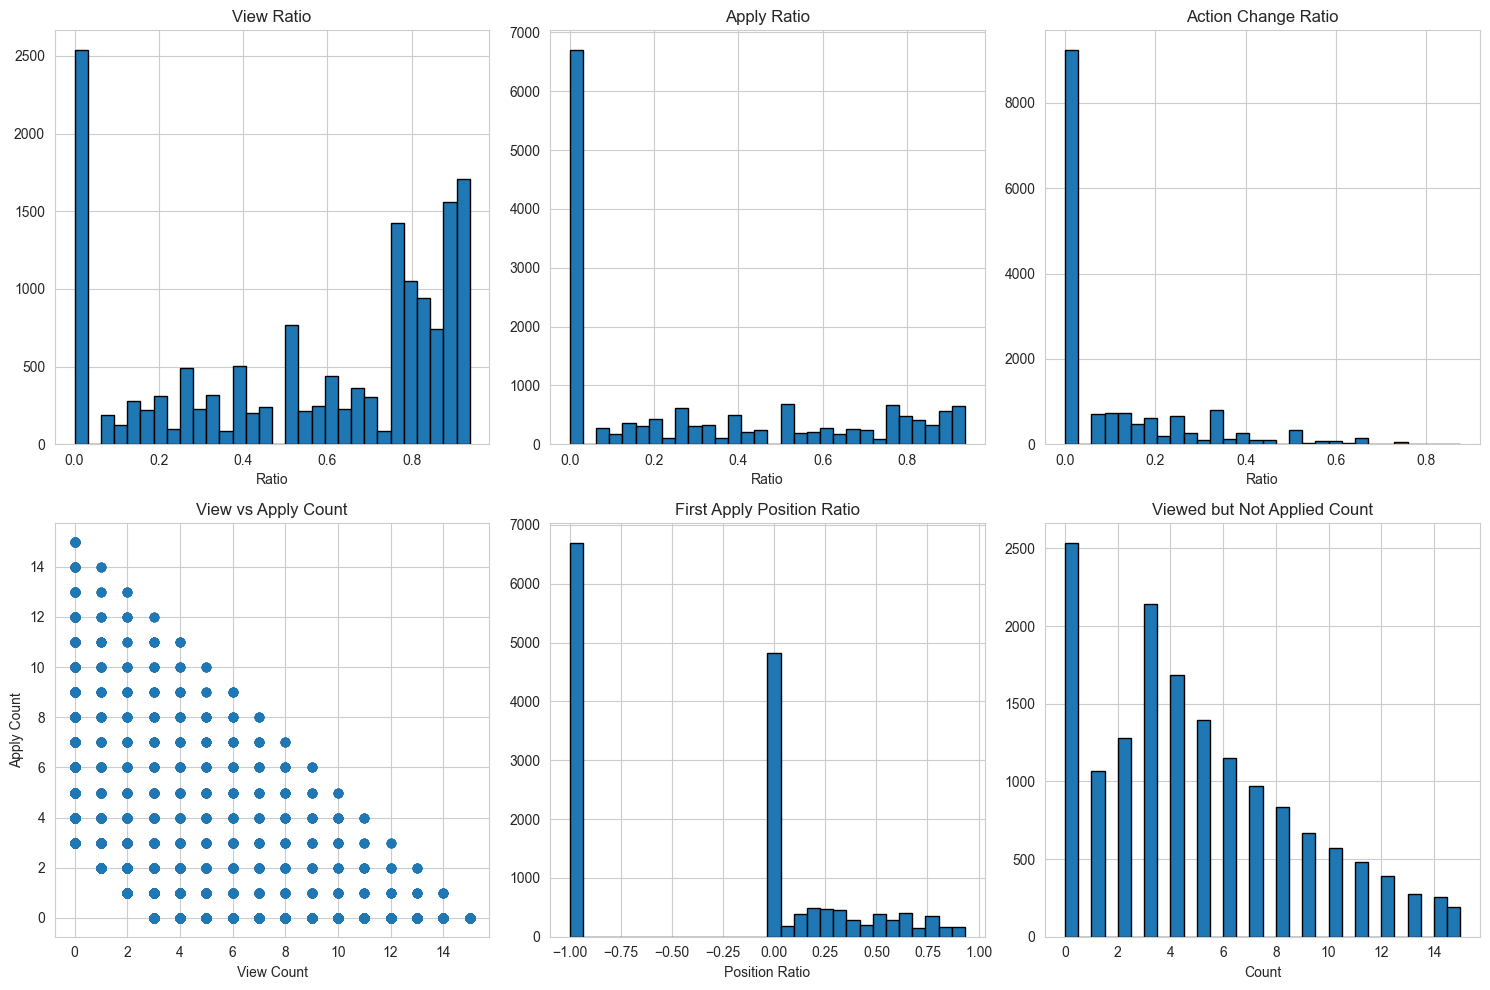

In [7]:
# Visualize session behavior features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].hist(x_train_session['view_ratio'], bins=30, edgecolor='black')
axes[0, 0].set_title('View Ratio')
axes[0, 0].set_xlabel('Ratio')

axes[0, 1].hist(x_train_session['apply_ratio'], bins=30, edgecolor='black')
axes[0, 1].set_title('Apply Ratio')
axes[0, 1].set_xlabel('Ratio')

axes[0, 2].hist(x_train_session['action_change_ratio'], bins=30, edgecolor='black')
axes[0, 2].set_title('Action Change Ratio')
axes[0, 2].set_xlabel('Ratio')

axes[1, 0].scatter(x_train_session['view_count'], x_train_session['apply_count'], alpha=0.3)
axes[1, 0].set_title('View vs Apply Count')
axes[1, 0].set_xlabel('View Count')
axes[1, 0].set_ylabel('Apply Count')

axes[1, 1].hist(x_train_session['first_apply_position_ratio'], bins=30, edgecolor='black')
axes[1, 1].set_title('First Apply Position Ratio')
axes[1, 1].set_xlabel('Position Ratio')

axes[1, 2].hist(x_train_session['viewed_not_applied_count'], bins=30, edgecolor='black')
axes[1, 2].set_title('Viewed but Not Applied Count')
axes[1, 2].set_xlabel('Count')

plt.tight_layout()
plt.show()

## 5. Extract Job Text Features (NLP)
Features based on text similarity between jobs using TF-IDF and cosine similarity

In [8]:
# Debug: Check jobs structure
print(f"Jobs type: {type(jobs)}")
print(f"Jobs length: {len(jobs)}")
if isinstance(jobs, dict):
    first_key = list(jobs.keys())[0]
    print(f"First key type: {type(first_key)}, value: {first_key}")
    print(f"First job data: {jobs[first_key]}")
elif isinstance(jobs, list):
    print(f"First job: {jobs[0]}")
    if jobs and 'JobId' in jobs[0]:
        print("Jobs is a list of dictionaries with JobId")


Jobs type: <class 'dict'>
Jobs length: 21917
First key type: <class 'str'>, value: 0
First job data: TITLE
QA Intégration / Data Analyst - SalesForces Sales Cloud 

SUMMARY
Responsabilités :
Assurer la qualité des données intégrées entre Salesforce et d'autres systèmes (SAP, autres produits).
Développer et exécuter des plans de tests pour les fonctionnalités Salesforce Sales Cloud.
Identifier, documenter et suivre les anomalies jusqu'à leur résolution.
Collaborer avec les équipes de développement pour comprendre les besoins et les spécifications.
Effectuer des analyses de données pour soutenir les décisions métier et améliorer les processus.
Participer à la qualification fonctionnelle des solutions en évolution.
Contribuer à la documentation des processus et des configurations

SECTION:
DESCRIPTION: Responsabilités :
Assurer la qualité des données intégrées entre Salesforce et d'autres systèmes (SAP, autres produits).
Développer et exécuter des plans de te

In [10]:
# Extract text features (this takes longer due to NLP processing)
print("Extracting NLP-based text features (this may take a few minutes)...")
x_train_text = processor.add_features(x_train_session.head(1000), feature_types=['text'])  # Start with subset

# Display new text features
text_cols = [col for col in x_train_text.columns if col not in x_train_session.columns]
print(f"\nText similarity features added ({len(text_cols)}):")
print(text_cols)

# Show sample
x_train_text[['session_id', 'avg_job_similarity', 'max_job_similarity', 
              'first_last_similarity', 'avg_skills_count', 'total_skills_count']].head(10)

Extracting NLP-based text features (this may take a few minutes)...
Extracting job text features with NLP...

Text similarity features added (9):
['avg_job_similarity', 'max_job_similarity', 'min_job_similarity', 'first_last_similarity', 'avg_skills_count', 'total_skills_count', 'has_finance_job', 'has_tech_job', 'has_management_job']


,session_id,avg_job_similarity,max_job_similarity,first_last_similarity,avg_skills_count,total_skills_count
0,0,0.278801,0.447632,0.357106,12.200000,55
1,1,0.260750,0.351441,0.274624,11.000000,38
2,2,0.286276,0.369298,0.403028,5.000000,27
3,3,0.268602,0.328246,0.272813,9.750000,55
4,4,0.306206,0.407158,0.377097,5.166667,29
5,5,0.233902,0.319201,0.386412,6.500000,19
6,6,0.269989,0.395575,0.242530,7.000000,22
7,7,0.205360,0.243298,0.297048,6.666667,19
8,8,0.290271,0.304606,0.213329,5.500000,22
9,9,0.244262,0.323759,0.272811,8.111111,52


## 5.5. Extract Transition and View Influence Features
Features that capture:
- What users were transitioning to (job changes, patterns)
- How viewing behavior influenced application decisions

In [14]:
def extract_revised_behavioral_features(df):
    """
    Extract features that make sense when each action is on a different job
    Focus on behavioral patterns rather than same-job revisits
    """
    result_df = df.copy()
    
    # 1. Action switching frequency (how often user changes from view to apply or vice versa)
    def action_switching_rate(row):
        actions = row['actions_list']
        if len(actions) <= 1:
            return 0.0
        
        switches = sum(1 for i in range(len(actions)-1) 
                      if actions[i] != actions[i+1])
        return switches / (len(actions) - 1)
    
    result_df['action_switching_rate'] = df.apply(action_switching_rate, axis=1)
    
    # 2. View phase length (how many consecutive views before first apply)
    def initial_view_phase(row):
        actions = row['actions_list']
        if 'apply' not in actions:
            return len(actions)  # All views
        
        first_apply = actions.index('apply')
        return sum(1 for i in range(first_apply) if actions[i] == 'view')
    
    result_df['initial_view_phase_length'] = df.apply(initial_view_phase, axis=1)
    
    # 3. Apply phase length (consecutive applies once they start)
    def final_apply_phase(row):
        actions = row['actions_list']
        if 'apply' not in actions:
            return 0
        
        # Count from last view to end
        last_view = max([i for i, a in enumerate(actions) if a == 'view'], default=-1)
        if last_view == -1:  # All applies
            return len(actions)
        
        return sum(1 for i in range(last_view+1, len(actions)) if actions[i] == 'apply')
    
    result_df['final_apply_phase_length'] = df.apply(final_apply_phase, axis=1)
    
    # 4. Decision point (where in session does behavior shift from explore to commit)
    def decision_point_ratio(row):
        actions = row['actions_list']
        if 'apply' not in actions:
            return 1.0  # Never decided to apply
        
        first_apply = actions.index('apply')
        return first_apply / len(actions)
    
    result_df['decision_point_ratio'] = df.apply(decision_point_ratio, axis=1)
    
    # 5. Commitment level (ratio of applies once they start applying)
    def commitment_level(row):
        actions = row['actions_list']
        if 'apply' not in actions:
            return 0.0
        
        first_apply = actions.index('apply')
        actions_after_first_apply = actions[first_apply:]
        applies_after = sum(1 for a in actions_after_first_apply if a == 'apply')
        
        return applies_after / len(actions_after_first_apply)
    
    result_df['commitment_level'] = df.apply(commitment_level, axis=1)
    
    # 6. View-apply interleaving (how much they mix views and applies)
    def interleaving_score(row):
        actions = row['actions_list']
        if len(actions) <= 1:
            return 0.0
        
        # Count transitions between view and apply
        transitions = sum(1 for i in range(len(actions)-1) 
                         if (actions[i] == 'view' and actions[i+1] == 'apply') or
                            (actions[i] == 'apply' and actions[i+1] == 'view'))
        
        return transitions / (len(actions) - 1)
    
    result_df['view_apply_interleaving'] = df.apply(interleaving_score, axis=1)
    
    # 7. Job diversity in view phase
    def view_phase_diversity(row):
        jobs = row['jobs_list']
        actions = row['actions_list']
        
        if 'apply' not in actions:
            first_apply = len(actions)
        else:
            first_apply = actions.index('apply')
        
        view_jobs = [jobs[i] for i in range(first_apply) if actions[i] == 'view']
        if not view_jobs:
            return 0
        
        return len(set(view_jobs)) / len(view_jobs)
    
    result_df['view_phase_diversity'] = df.apply(view_phase_diversity, axis=1)
    
    # 8. Job diversity in apply phase  
    def apply_phase_diversity(row):
        jobs = row['jobs_list']
        actions = row['actions_list']
        
        if 'apply' not in actions:
            return 0.0
        
        first_apply = actions.index('apply')
        apply_jobs = [jobs[i] for i in range(first_apply, len(jobs)) if actions[i] == 'apply']
        
        if not apply_jobs:
            return 0.0
        
        return len(set(apply_jobs)) / len(apply_jobs)
    
    result_df['apply_phase_diversity'] = df.apply(apply_phase_diversity, axis=1)
    
    # 9. Exploration to application ratio
    def exploration_application_ratio(row):
        view_count = sum(1 for a in row['actions_list'] if a == 'view')
        apply_count = sum(1 for a in row['actions_list'] if a == 'apply')
        
        if apply_count == 0:
            return float('inf') if view_count > 0 else 0
        
        return view_count / apply_count
    
    result_df['exploration_to_application_ratio'] = df.apply(exploration_application_ratio, axis=1)
    # Handle infinity values
    result_df['exploration_to_application_ratio'] = result_df['exploration_to_application_ratio'].replace([np.inf, -np.inf], 999)
    
    # 10. Session focus (how concentrated are applies on specific job)
    def session_focus(row):
        jobs = row['jobs_list']
        actions = row['actions_list']
        
        apply_jobs = [jobs[i] for i, a in enumerate(actions) if a == 'apply']
        if not apply_jobs:
            return 0.0
        
        from collections import Counter
        job_counts = Counter(apply_jobs)
        most_common_count = job_counts.most_common(1)[0][1]
        
        return most_common_count / len(apply_jobs)
    
    result_df['apply_focus_score'] = df.apply(session_focus, axis=1)
    
    # 11. Browse-then-batch pattern (many views then many applies)
    def browse_then_batch(row):
        actions = row['actions_list']
        if len(actions) < 4:
            return 0
        
        # Check if first half is mostly views and second half is mostly applies
        midpoint = len(actions) // 2
        first_half = actions[:midpoint]
        second_half = actions[midpoint:]
        
        view_ratio_first = sum(1 for a in first_half if a == 'view') / len(first_half)
        apply_ratio_second = sum(1 for a in second_half if a == 'apply') / len(second_half)
        
        return (view_ratio_first + apply_ratio_second) / 2
    
    result_df['browse_then_batch_score'] = df.apply(browse_then_batch, axis=1)
    
    # 12. User decisiveness (how quickly they move to applying)
    def decisiveness_score(row):
        """Higher score = more decisive (applies early)"""
        actions = row['actions_list']
        if 'apply' not in actions:
            return 0.0
        
        first_apply_position = actions.index('apply')
        # Inverse of position ratio (earlier apply = higher score)
        return 1 - (first_apply_position / len(actions))
    
    result_df['decisiveness_score'] = df.apply(decisiveness_score, axis=1)
    
    print(f"\nRevised behavioral features added: {len([c for c in result_df.columns if c not in df.columns])}")
    return result_df

# Apply to your data
x_train_revised = extract_revised_behavioral_features(x_train_session)

# Show new features
new_cols = [col for col in x_train_revised.columns if col not in x_train_session.columns]
print(f"\nNew feature columns:")
for col in new_cols:
    print(f"  - {col}")

# Display sample
display_cols = ['session_id', 'action_switching_rate', 'initial_view_phase_length', 
                'decision_point_ratio', 'commitment_level', 'decisiveness_score']
x_train_revised[display_cols].head(10)


Revised behavioral features added: 12

New feature columns:
  - action_switching_rate
  - initial_view_phase_length
  - final_apply_phase_length
  - decision_point_ratio
  - commitment_level
  - view_apply_interleaving
  - view_phase_diversity
  - apply_phase_diversity
  - exploration_to_application_ratio
  - apply_focus_score
  - browse_then_batch_score
  - decisiveness_score


,session_id,action_switching_rate,initial_view_phase_length,decision_point_ratio,commitment_level,decisiveness_score
0,0,0.000000,8,1.000000,0.0,0.000000
1,1,0.000000,4,1.000000,0.0,0.000000
2,2,0.166667,2,0.285714,1.0,0.714286
3,3,0.000000,0,0.000000,1.0,1.000000
4,4,0.000000,0,0.000000,1.0,1.000000
5,5,0.000000,0,0.000000,1.0,1.000000
6,6,0.000000,0,0.000000,1.0,1.000000
7,7,0.000000,0,0.000000,1.0,1.000000
8,8,0.000000,0,0.000000,1.0,1.000000
9,9,0.000000,0,0.000000,1.0,1.000000


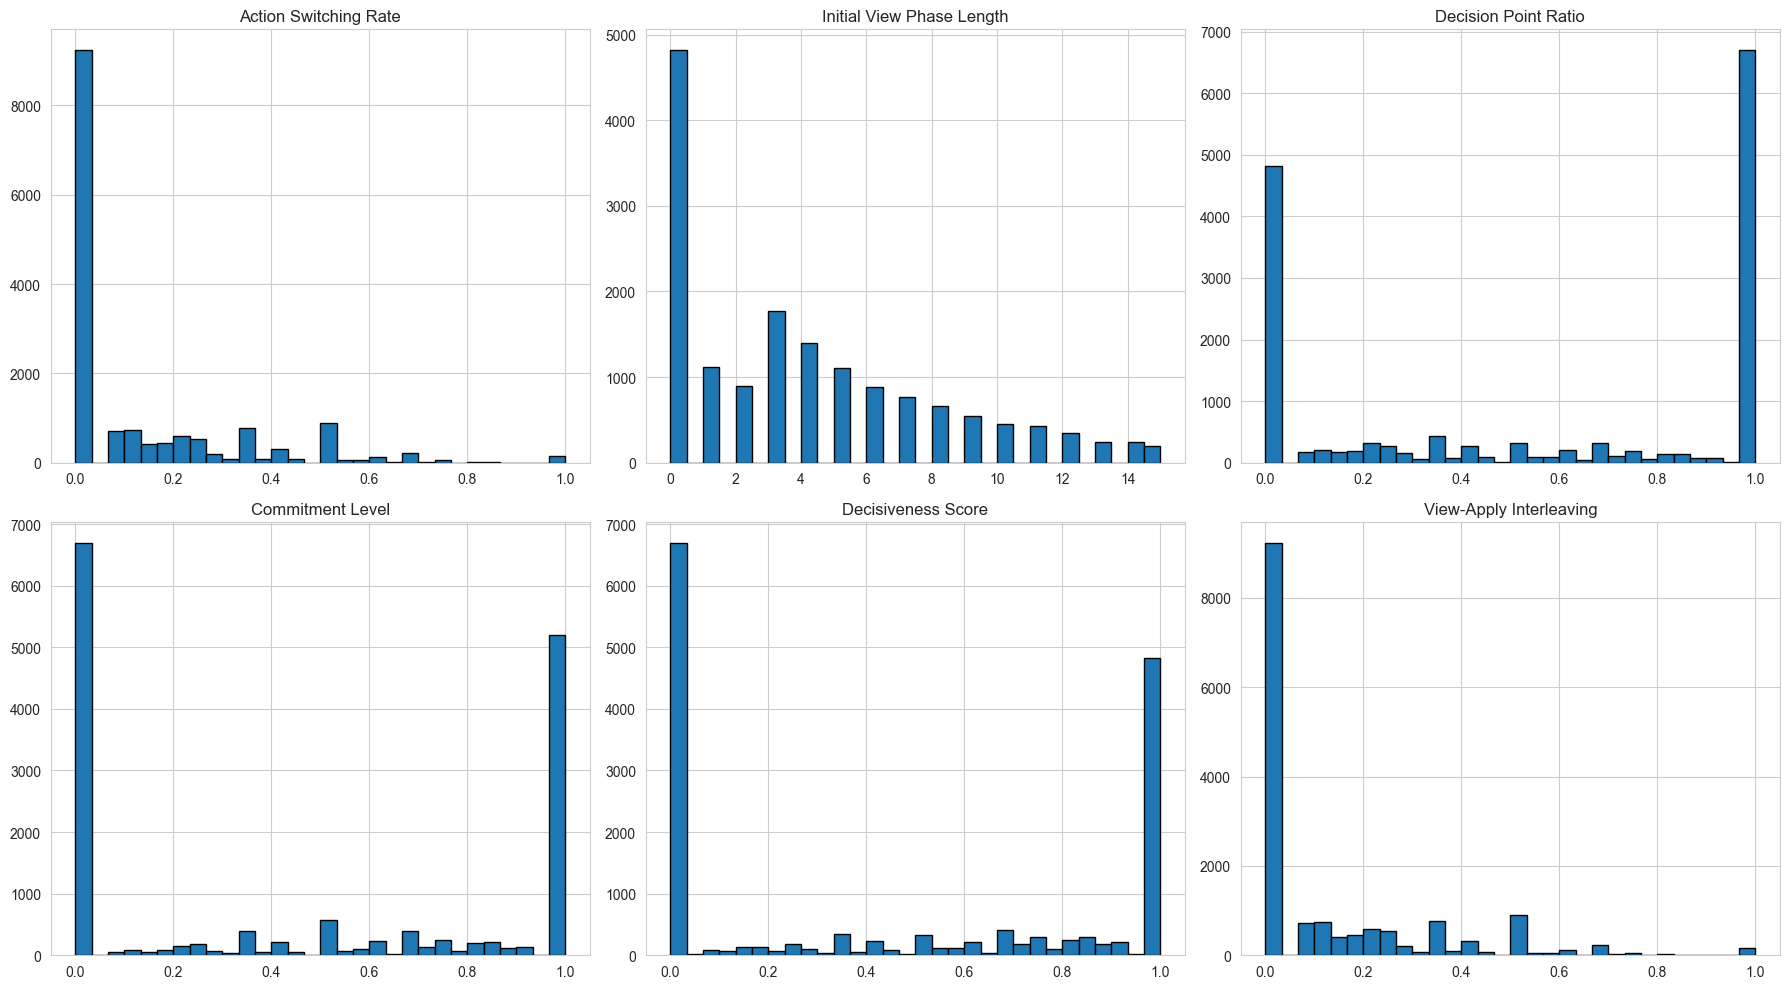

In [15]:
# Visualize the revised features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].hist(x_train_revised['action_switching_rate'], bins=30, edgecolor='black')
axes[0, 0].set_title('Action Switching Rate')

axes[0, 1].hist(x_train_revised['initial_view_phase_length'], bins=30, edgecolor='black')
axes[0, 1].set_title('Initial View Phase Length')

axes[0, 2].hist(x_train_revised['decision_point_ratio'], bins=30, edgecolor='black')
axes[0, 2].set_title('Decision Point Ratio')

axes[1, 0].hist(x_train_revised['commitment_level'], bins=30, edgecolor='black')
axes[1, 0].set_title('Commitment Level')

axes[1, 1].hist(x_train_revised['decisiveness_score'], bins=30, edgecolor='black')
axes[1, 1].set_title('Decisiveness Score')

axes[1, 2].hist(x_train_revised['view_apply_interleaving'], bins=30, edgecolor='black')
axes[1, 2].set_title('View-Apply Interleaving')

plt.tight_layout()
plt.show()

In [18]:
# Analyze key insights from transition features
print("=" * 70)
print("KEY INSIGHTS: How Views Influence Apply Decisions")
print("=" * 70)# Analyze key insights from revised behavioral features
print("=" * 70)
print("KEY INSIGHTS: Behavioral Patterns in Job Applications")
print("=" * 70)

# 1. Decision-making speed
print("\n1. DECISION-MAKING SPEED:")
print(f"   Average decisiveness score: {x_train_revised['decisiveness_score'].mean():.2%}")
print(f"   Highly decisive users (score > 0.7): {(x_train_revised['decisiveness_score'] > 0.7).sum()}")
print(f"   Average decision point ratio: {x_train_revised['decision_point_ratio'].mean():.2%}")

# 2. Exploration vs commitment
print("\n2. EXPLORATION VS COMMITMENT:")
print(f"   Average initial view phase: {x_train_revised['initial_view_phase_length'].mean():.1f} jobs")
print(f"   Average final apply phase: {x_train_revised['final_apply_phase_length'].mean():.1f} jobs")
print(f"   Average commitment level: {x_train_revised['commitment_level'].mean():.2%}")

# 3. Behavioral patterns
print("\n3. BEHAVIORAL PATTERNS:")
print(f"   Average action switching rate: {x_train_revised['action_switching_rate'].mean():.2%}")
print(f"   Average view-apply interleaving: {x_train_revised['view_apply_interleaving'].mean():.2%}")
print(f"   Browse-then-batch pattern score: {x_train_revised['browse_then_batch_score'].mean():.2%}")

# 4. Job exploration
print("\n4. JOB EXPLORATION:")
print(f"   Average view phase diversity: {x_train_revised['view_phase_diversity'].mean():.2%}")
print(f"   Average apply phase diversity: {x_train_revised['apply_phase_diversity'].mean():.2%}")
print(f"   Average exploration/application ratio: {x_train_revised['exploration_to_application_ratio'].mean():.2f}")

# 5. Focus and targeting
print("\n5. APPLICATION FOCUS:")
print(f"   Average apply focus score: {x_train_revised['apply_focus_score'].mean():.2%}")
print(f"   Highly focused users (score > 0.8): {(x_train_revised['apply_focus_score'] > 0.8).sum()}")

print("\n" + "=" * 70)

KEY INSIGHTS: How Views Influence Apply Decisions
KEY INSIGHTS: Behavioral Patterns in Job Applications

1. DECISION-MAKING SPEED:
   Average decisiveness score: 45.74%
   Highly decisive users (score > 0.7): 6337
   Average decision point ratio: 54.26%

2. EXPLORATION VS COMMITMENT:
   Average initial view phase: 4.0 jobs
   Average final apply phase: 1.9 jobs
   Average commitment level: 46.17%

3. BEHAVIORAL PATTERNS:
   Average action switching rate: 13.03%
   Average view-apply interleaving: 13.03%
   Browse-then-batch pattern score: 45.75%

4. JOB EXPLORATION:
   Average view phase diversity: 69.39%
   Average apply phase diversity: 57.58%
   Average exploration/application ratio: 422.26

5. APPLICATION FOCUS:
   Average apply focus score: 21.85%
   Highly focused users (score > 0.8): 1529



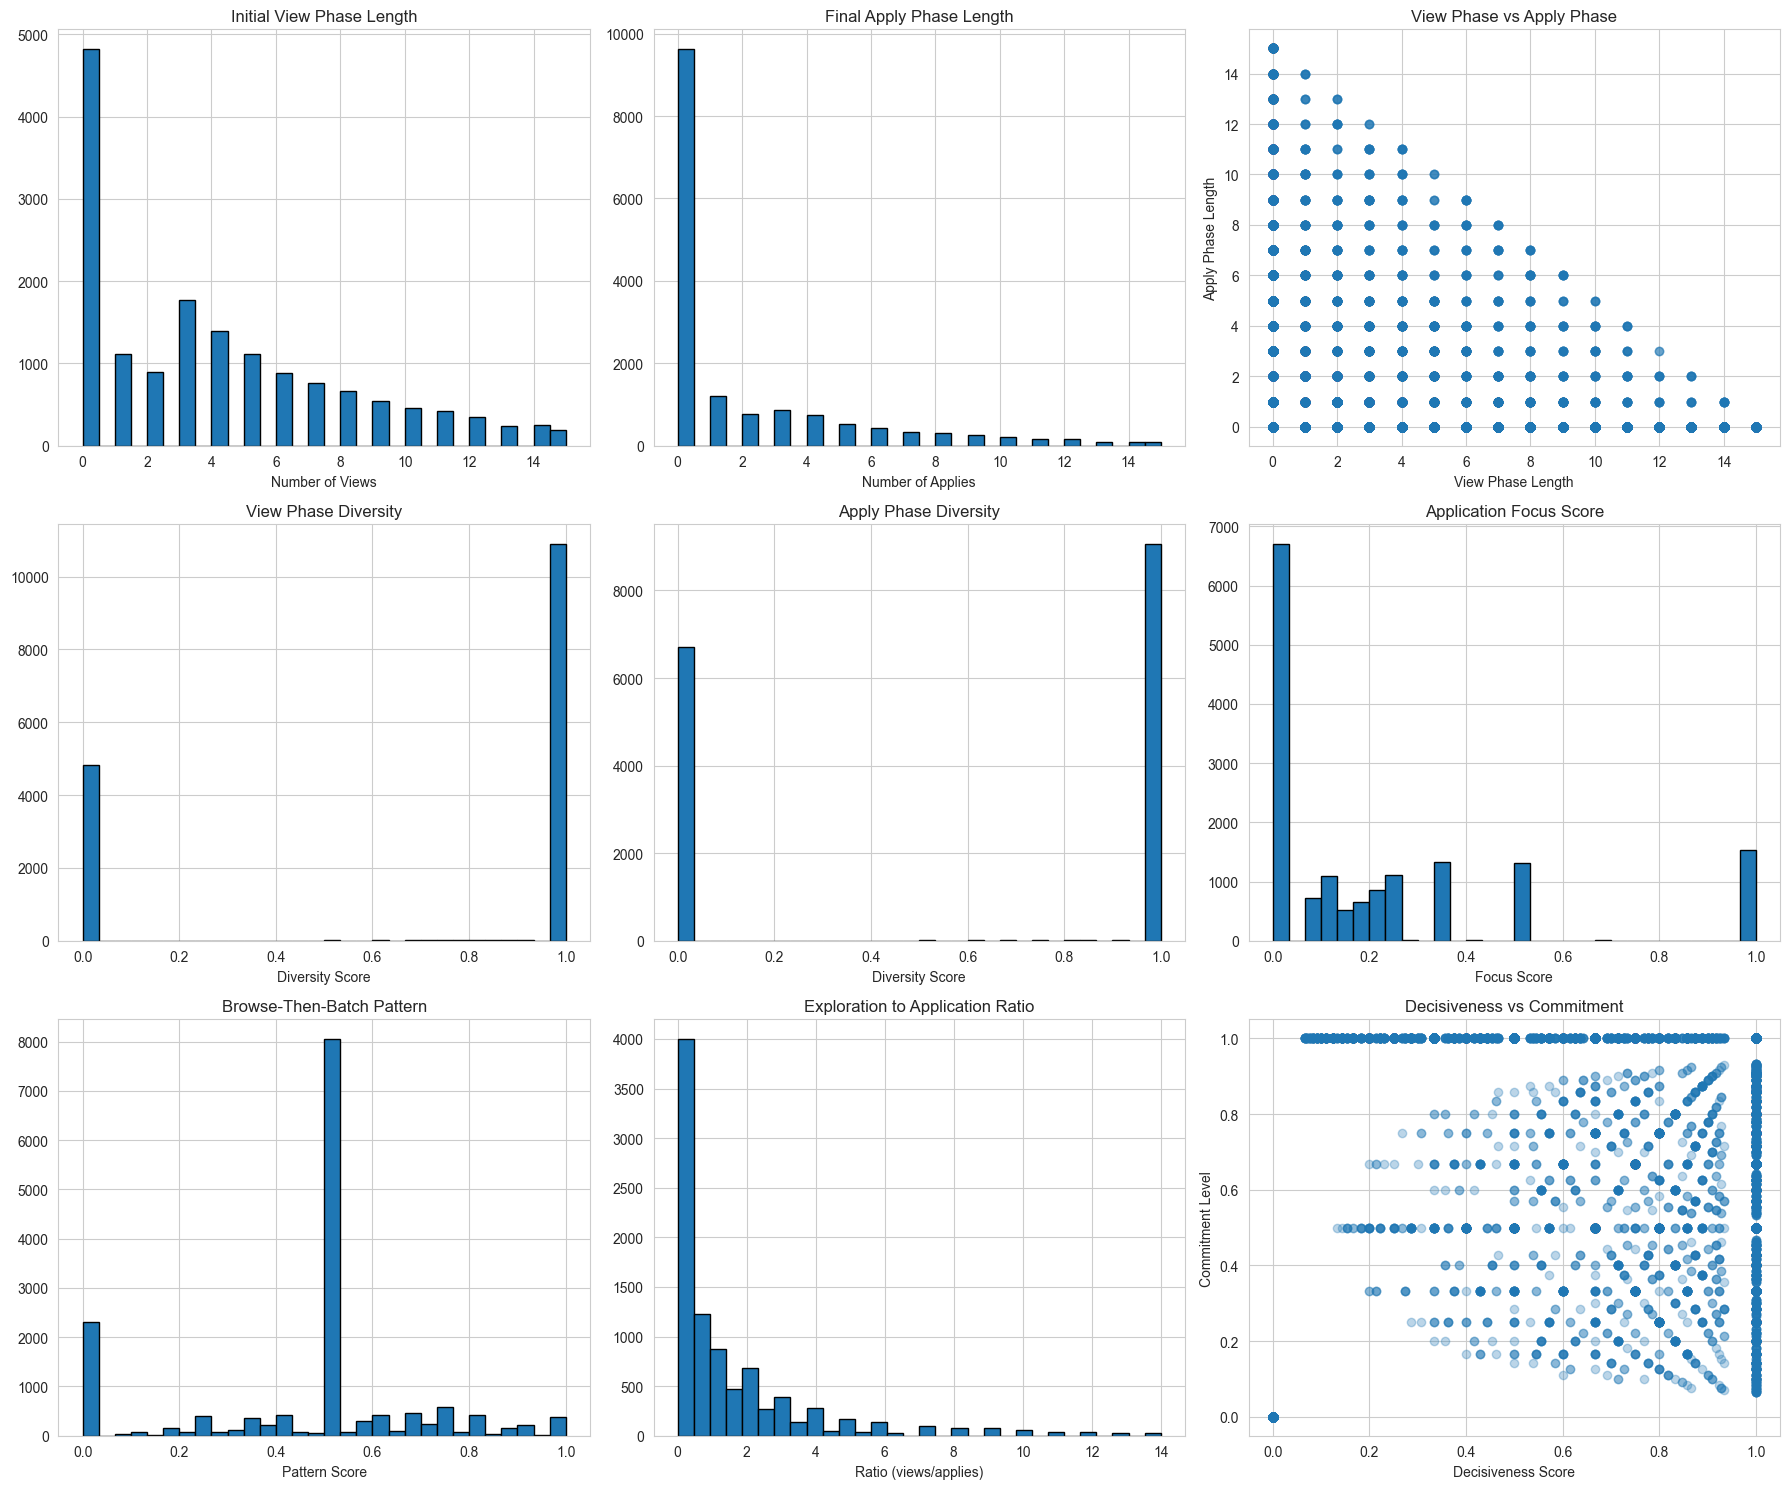

In [19]:
# Additional visualizations for behavioral patterns
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# Row 1: Phase analysis
axes[0, 0].hist(x_train_revised['initial_view_phase_length'], bins=30, edgecolor='black')
axes[0, 0].set_title('Initial View Phase Length')
axes[0, 0].set_xlabel('Number of Views')

axes[0, 1].hist(x_train_revised['final_apply_phase_length'], bins=30, edgecolor='black')
axes[0, 1].set_title('Final Apply Phase Length')
axes[0, 1].set_xlabel('Number of Applies')

axes[0, 2].scatter(x_train_revised['initial_view_phase_length'], 
                   x_train_revised['final_apply_phase_length'], alpha=0.3)
axes[0, 2].set_title('View Phase vs Apply Phase')
axes[0, 2].set_xlabel('View Phase Length')
axes[0, 2].set_ylabel('Apply Phase Length')

# Row 2: Diversity analysis
axes[1, 0].hist(x_train_revised['view_phase_diversity'], bins=30, edgecolor='black')
axes[1, 0].set_title('View Phase Diversity')
axes[1, 0].set_xlabel('Diversity Score')

axes[1, 1].hist(x_train_revised['apply_phase_diversity'], bins=30, edgecolor='black')
axes[1, 1].set_title('Apply Phase Diversity')
axes[1, 1].set_xlabel('Diversity Score')

axes[1, 2].hist(x_train_revised['apply_focus_score'], bins=30, edgecolor='black')
axes[1, 2].set_title('Application Focus Score')
axes[1, 2].set_xlabel('Focus Score')

# Row 3: Pattern analysis
axes[2, 0].hist(x_train_revised['browse_then_batch_score'], bins=30, edgecolor='black')
axes[2, 0].set_title('Browse-Then-Batch Pattern')
axes[2, 0].set_xlabel('Pattern Score')

# Filter out extreme values for better visualization
exploration_ratios = x_train_revised['exploration_to_application_ratio']
exploration_ratios_filtered = exploration_ratios[exploration_ratios < 20]
axes[2, 1].hist(exploration_ratios_filtered, bins=30, edgecolor='black')
axes[2, 1].set_title('Exploration to Application Ratio')
axes[2, 1].set_xlabel('Ratio (views/applies)')

axes[2, 2].scatter(x_train_revised['decisiveness_score'], 
                   x_train_revised['commitment_level'], alpha=0.3)
axes[2, 2].set_title('Decisiveness vs Commitment')
axes[2, 2].set_xlabel('Decisiveness Score')
axes[2, 2].set_ylabel('Commitment Level')

plt.tight_layout()
plt.show()

## 6. Extract All Features at Once

In [20]:
# Extract all features including revised behavioral patterns
print("Extracting all features for training set (sample)...")

# First extract sequence and session features
x_train_sample = processor.add_features(x_train.head(500), feature_types=['sequence', 'session'])

# Then add revised behavioral features
x_train_all = extract_revised_behavioral_features(x_train_sample)

# Add text features (slower)
x_train_all = processor.add_features(x_train_all, feature_types=['text'])

print(f"\nOriginal columns: {x_train.shape[1]}")
print(f"With all features: {x_train_all.shape[1]}")
print(f"New features added: {x_train_all.shape[1] - x_train.shape[1]}")

# Show all column names
print("\nAll feature columns:")
for col in x_train_all.columns:
    print(f"  - {col}")

Extracting all features for training set (sample)...
Extracting sequence features...
Extracting session behavior features...

Revised behavioral features added: 12
Extracting job text features with NLP...

Original columns: 6
With all features: 58
New features added: 52

All feature columns:
  - session_id
  - job_ids
  - actions
  - jobs_list
  - actions_list
  - seq_length
  - first_job
  - last_job
  - second_job
  - second_last_job
  - unique_jobs_count
  - unique_jobs_ratio
  - most_frequent_job
  - most_frequent_job_count
  - most_frequent_job_ratio
  - job_last_positions
  - avg_job_position
  - job_transitions
  - job_transitions_ratio
  - max_consecutive_views
  - avg_consecutive_views
  - view_count
  - apply_count
  - view_ratio
  - apply_ratio
  - first_action_is_apply
  - last_action_is_apply
  - view_to_apply_count
  - apply_to_view_count
  - action_change_ratio
  - first_apply_position
  - first_apply_position_ratio
  - applied_jobs
  - applied_jobs_count
  - unique_appl

## 7. Feature Statistics Summary

In [21]:
# Process full datasets with revised features
print("Processing full training set...")
x_train_features = processor.add_features(x_train, feature_types=['sequence', 'session'])
x_train_features = extract_revised_behavioral_features(x_train_features)

print("Processing test set...")
x_test_features = processor.add_features(x_test, feature_types=['sequence', 'session'])
x_test_features = extract_revised_behavioral_features(x_test_features)

# Save to CSV
x_train_features.to_csv('../Data/x_train_with_features.csv', index=False)
x_test_features.to_csv('../Data/x_test_with_features.csv', index=False)

print("\nFeatures saved!")
print(f"Training set: {x_train_features.shape}")
print(f"Test set: {x_test_features.shape}")

Processing full training set...
Extracting sequence features...
Extracting session behavior features...

Revised behavioral features added: 12
Processing test set...
Extracting sequence features...
Extracting session behavior features...

Revised behavioral features added: 12

Features saved!
Training set: (15882, 49)
Test set: (1819, 49)


## 8. Feature Correlation Analysis

Analyzing correlations for 50 numeric features


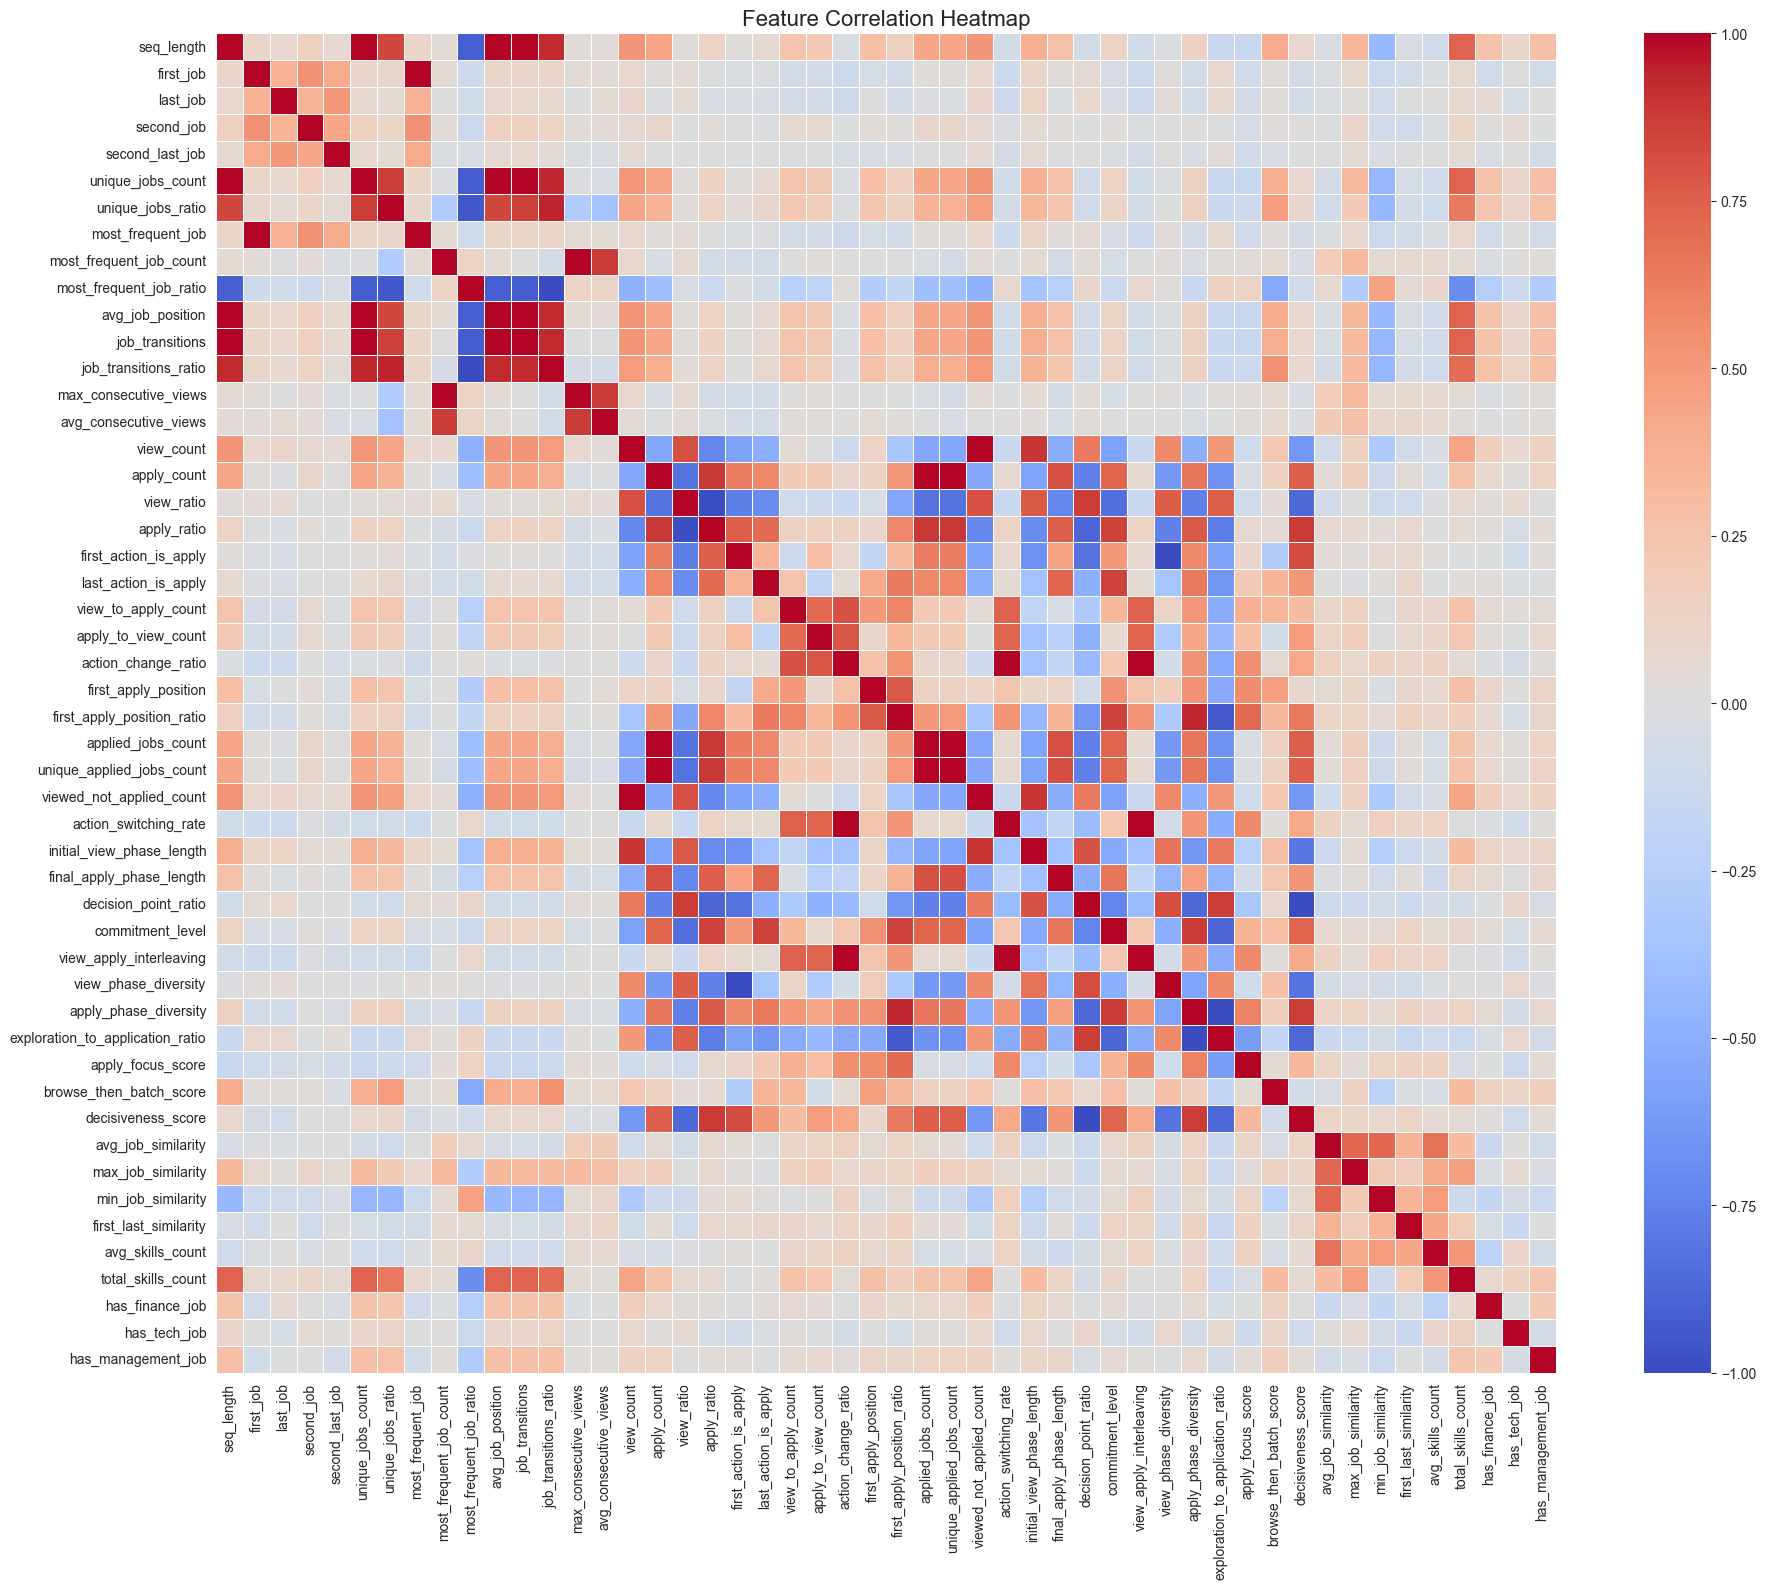


Highly Correlated Features (|correlation| > 0.8):
  decision_point_ratio <-> decisiveness_score: -1.000
  seq_length <-> avg_job_position: 1.000
  most_frequent_job_count <-> max_consecutive_views: 1.000
  apply_count <-> applied_jobs_count: 1.000
  action_switching_rate <-> view_apply_interleaving: 1.000
  first_job <-> most_frequent_job: 1.000
  unique_jobs_count <-> job_transitions: 0.999
  apply_count <-> unique_applied_jobs_count: 0.999
  applied_jobs_count <-> unique_applied_jobs_count: 0.999
  apply_phase_diversity <-> exploration_to_application_ratio: -0.999
  seq_length <-> job_transitions: 0.999
  avg_job_position <-> job_transitions: 0.999
  view_count <-> viewed_not_applied_count: 0.999
  first_action_is_apply <-> view_phase_diversity: -0.997
  seq_length <-> unique_jobs_count: 0.997
  unique_jobs_count <-> avg_job_position: 0.997
  most_frequent_job_ratio <-> job_transitions_ratio: -0.995
  action_change_ratio <-> action_switching_rate: 0.992
  action_change_ratio <-> vie

In [24]:
## 8. Feature Correlation Analysis

# Get all numeric feature columns (excluding original columns and lists)
numeric_cols = x_train_all.select_dtypes(include=[np.number]).columns.tolist()
# Exclude session_id
feature_cols = [col for col in numeric_cols if col != 'session_id']

print(f"Analyzing correlations for {len(feature_cols)} numeric features")

# Calculate correlation matrix
correlation_matrix = x_train_all[feature_cols].corr()

# Plot heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()

# Find highly correlated feature pairs
print("\nHighly Correlated Features (|correlation| > 0.8):")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {feat1} <-> {feat2}: {corr:.3f}")
else:
    print("  No highly correlated feature pairs found")

## 9. Save Processed Features

In [25]:
## 9. Final Summary and Export

# Display final feature counts
print("=" * 70)
print("FINAL FEATURE ENGINEERING SUMMARY")
print("=" * 70)

print(f"\nTraining Set:")
print(f"  Total rows: {x_train_features.shape[0]:,}")
print(f"  Total columns: {x_train_features.shape[1]}")
print(f"  Original columns: {x_train.shape[1]}")
print(f"  New features added: {x_train_features.shape[1] - x_train.shape[1]}")

print(f"\nTest Set:")
print(f"  Total rows: {x_test_features.shape[0]:,}")
print(f"  Total columns: {x_test_features.shape[1]}")

print(f"\nFeature Categories:")
all_features = [col for col in x_train_features.columns 
                if col not in ['session_id', 'jobs', 'actions', 'jobs_list', 'actions_list']]

sequence_features = [col for col in all_features if col in [
    'seq_length', 'unique_jobs_count', 'unique_jobs_ratio', 
    'most_frequent_job_count', 'most_frequent_job_ratio',
    'job_transitions', 'job_transitions_ratio', 
    'max_consecutive_views', 'avg_consecutive_views', 'avg_job_position'
]]

session_features = [col for col in all_features if col in [
    'view_count', 'apply_count', 'view_ratio', 'apply_ratio',
    'action_change_ratio', 'first_apply_position_ratio',
    'view_to_apply_count', 'viewed_not_applied_count'
]]

revised_features = [col for col in all_features if col in [
    'action_switching_rate', 'initial_view_phase_length', 'final_apply_phase_length',
    'decision_point_ratio', 'commitment_level', 'view_apply_interleaving',
    'view_phase_diversity', 'apply_phase_diversity', 'exploration_to_application_ratio',
    'apply_focus_score', 'browse_then_batch_score', 'decisiveness_score'
]]

print(f"  Sequence features: {len(sequence_features)}")
print(f"  Session features: {len(session_features)}")
print(f"  Revised behavioral features: {len(revised_features)}")
print(f"  Other features: {len(all_features) - len(sequence_features) - len(session_features) - len(revised_features)}")

print(f"\nFiles saved:")
print(f"  ../Data/x_train_with_features.csv")
print(f"  ../Data/x_test_with_features.csv")

print("\n" + "=" * 70)
print("✓ Feature engineering complete!")
print("=" * 70)

FINAL FEATURE ENGINEERING SUMMARY

Training Set:
  Total rows: 15,882
  Total columns: 49
  Original columns: 6
  New features added: 43

Test Set:
  Total rows: 1,819
  Total columns: 49

Feature Categories:
  Sequence features: 10
  Session features: 8
  Revised behavioral features: 12
  Other features: 15

Files saved:
  ../Data/x_train_with_features.csv
  ../Data/x_test_with_features.csv

✓ Feature engineering complete!
